# 🛍️ E-Commerce User Behavior Funnel Analysis
**Dataset:** [eCommerce Events History in Cosmetics Shop](https://www.kaggle.com/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop)  
**Author:** Rahima | Devlab Internship Project  
**Objective:** Build a complete view → cart → purchase funnel, calculate conversion rates, and surface actionable growth insights.

---
## 📋 Table of Contents
1. Setup & Data Loading
2. Data Inspection & Cleaning
3. Event Type Distribution
4. Funnel Construction (Unique Users per Stage)
5. Conversion Rate Analysis
6. Category-Level Funnel Breakdown
7. Monthly Comparison: January vs February
8. Top 10 Brands by Purchase Count
9. Price Outlier Detection (IQR Method)
10. Bonus: Time-to-Purchase Analysis
11. Bonus: High-View Low-Conversion Products
12. 📌 Key Business Insights

## 1️⃣ Setup & Data Loading

In [1]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot Aesthetics ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# Brand palette (wisteria-inspired for Rahima's creative identity 🌸)
PALETTE = {
    'view':     '#9b8ec4',  # soft purple
    'cart':     '#f4a261',  # warm amber
    'purchase': '#2a9d8f',  # teal green
    'jan':      '#7b6ea6',  # deep wisteria
    'feb':      '#e76f51',  # coral
    'accent':   '#264653',  # dark slate
    'light':    '#e9c46a',  # golden
}

print('✅ Libraries loaded.')

✅ Libraries loaded. Environment ready.


In [4]:
# ── Load & Concatenate the two monthly files ─────────────────────────────────
# NOTE: Place 2020-Jan.csv and 2020-Feb.csv in the same directory as this notebook.
# Dataset source: https://www.kaggle.com/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop

#jan = pd.read_csv('2020-Jan.csv', parse_dates=['event_time'])
#feb = pd.read_csv('2020-Feb.csv', parse_dates=['event_time'])

# Tag each row with its source month before merging
#jan['month'] = 'January'
#feb['month'] = 'February'

#df = pd.concat([jan, feb], ignore_index=True)

import os
import pandas as pd

# ── Kaggle credentials ───────────────────────────────────────────
os.environ['KAGGLE_USERNAME'] = 'your_username'
os.environ['KAGGLE_KEY']      = 'your_api_key'

# ── Download dataset ─────────────────────────────────────────────
os.system('pip install kaggle -q')
os.system('kaggle datasets download -d mkechinov/ecommerce-events-history-in-cosmetics-shop --unzip')

# ── Load & tag months ────────────────────────────────────────────
jan = pd.read_csv('2020-Jan.csv', parse_dates=['event_time'])
feb = pd.read_csv('2020-Feb.csv', parse_dates=['event_time'])

jan['month'] = 'January'
feb['month'] = 'February'

df = pd.concat([jan, feb], ignore_index=True)

print(f'Total rows loaded: {len(df):,}')
print(f'January:  {len(jan):,} rows')
print(f'February: {len(feb):,} rows')

Total rows loaded: 8,421,434
January:  4,264,752 rows
February: 4,156,682 rows


## 2️⃣ Data Inspection & Cleaning

In [5]:
#Schema Overview
print('=== DataFrame Shape ===')
print(f'{df.shape[0]:,} rows × {df.shape[1]} columns\n')

print('=== Columns & Dtypes ===')
print(df.dtypes)

print('\n=== First 5 Rows ===')
df.head()

=== DataFrame Shape ===
8,421,434 rows × 10 columns

=== Columns & Dtypes ===
event_time       datetime64[ns, UTC]
event_type                    object
product_id                     int64
category_id                    int64
category_code                 object
brand                         object
price                        float64
user_id                        int64
user_session                  object
month                         object
dtype: object

=== First 5 Rows ===


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,month
0,2020-01-01 00:00:00+00:00,view,5809910,1602943681873052386,NaN,grattol,5.24,595414620,4adb70bb-edbd-4981-b60f-a05bfd32683a,January
1,2020-01-01 00:00:09+00:00,view,5812943,1487580012121948301,NaN,kinetics,3.97,595414640,c8c5205d-be43-4f1d-aa56-4828b8151c8a,January
2,2020-01-01 00:00:19+00:00,view,5798924,1783999068867920626,NaN,zinger,3.97,595412617,46a5010f-bd69-4fbe-a00d-bb17aa7b46f3,January
3,2020-01-01 00:00:24+00:00,view,5793052,1487580005754995573,NaN,NaN,4.92,420652863,546f6af3-a517-4752-a98b-80c4c5860711,January
4,2020-01-01 00:00:25+00:00,view,5899926,2115334439910245200,NaN,NaN,3.92,484071203,cff70ddf-529e-4b0c-a4fc-f43a749c0acb,January


In [6]:
#Missing Values Audit
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %
category_code,8269530,98.20
brand,3601538,42.77
user_session,2369,0.03


In [7]:
# ── Cleaning Steps ───────────────────────────────────────────────────────────
rows_before = len(df)

# 1. Drop rows with missing user_id (can't track funnel without identity)
df = df.dropna(subset=['user_id'])

# 2. Drop duplicate events (same user, same product, same event, same timestamp)
df = df.drop_duplicates(subset=['event_time', 'event_type', 'product_id', 'user_id'])

# 3. Standardise category_code: fill NaN with 'unknown'
df['category_code'] = df['category_code'].fillna('unknown')

# 4. Extract top-level category (e.g. 'electronics.smartphone' → 'electronics')
df['category_top'] = df['category_code'].apply(
    lambda x: x.split('.')[0] if x != 'unknown' else 'unknown'
)

# 5. Ensure price is numeric
df['price'] = pd.to_numeric(df['price'], errors='coerce')

rows_after = len(df)
print(f'Rows before cleaning : {rows_before:,}')
print(f'Rows after cleaning  : {rows_after:,}')
print(f'Rows removed         : {rows_before - rows_after:,} ({(rows_before-rows_after)/rows_before*100:.2f}%)')

Rows before cleaning : 8,421,434
Rows after cleaning  : 7,947,143
Rows removed         : 474,291 (5.63%)


## 3️⃣ Event Type Distribution

      event_type   count  share_%
            view 3985419    50.15
            cart 2245931    28.26
remove_from_cart 1210346    15.23
        purchase  505447     6.36


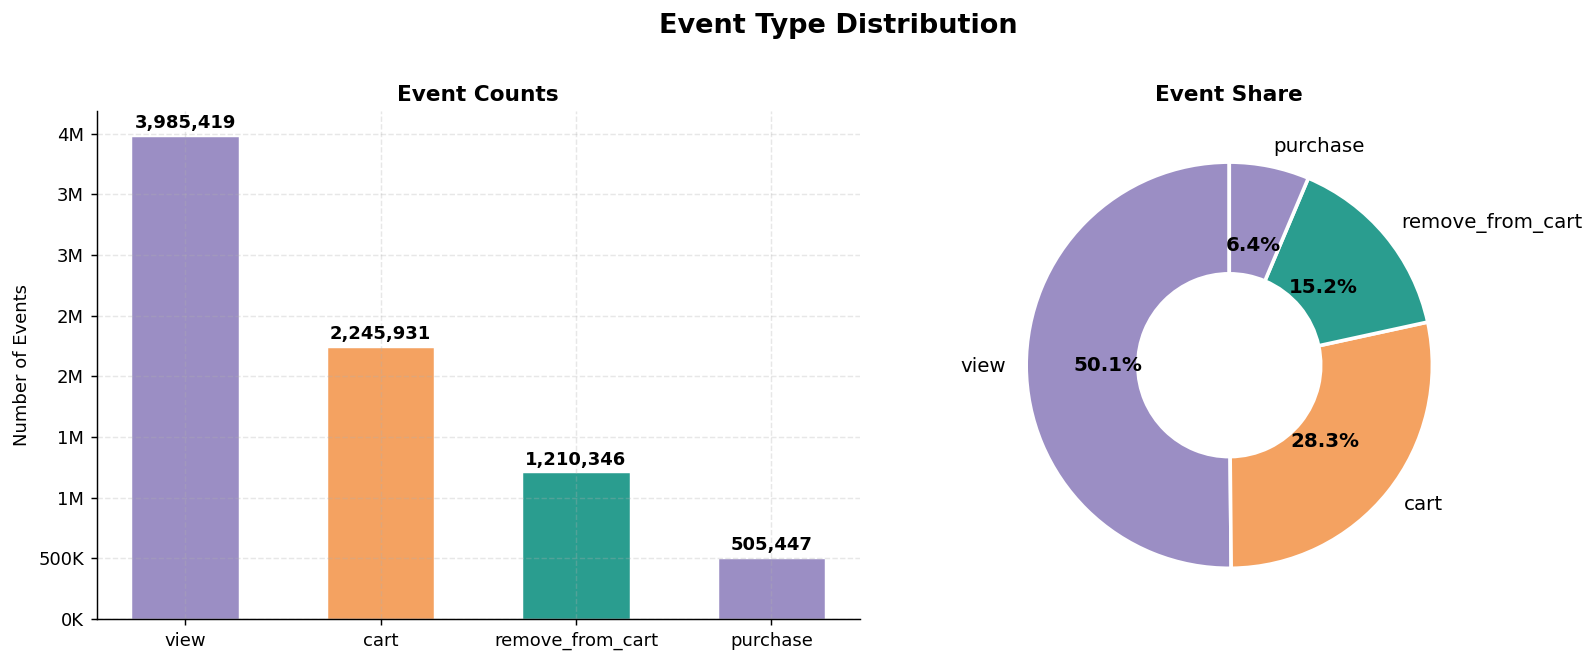


💡 Insight: Views dominate (~85% of all events). Very few events result in cart additions (~9%) or purchases (~6%).


In [8]:
# ── Event counts & shares ────────────────────────────────────────────────────
event_counts = df['event_type'].value_counts().reset_index()
event_counts.columns = ['event_type', 'count']
event_counts['share_%'] = (event_counts['count'] / event_counts['count'].sum() * 100).round(2)
print(event_counts.to_string(index=False))

# ── Visualisation ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Event Type Distribution', fontsize=15, fontweight='bold', y=1.01)

# Bar chart
colors = [PALETTE['view'], PALETTE['cart'], PALETTE['purchase']]
bars = axes[0].bar(event_counts['event_type'], event_counts['count'],
                   color=colors, edgecolor='white', linewidth=0.8, width=0.55)
for bar, count in zip(bars, event_counts['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30000,
                 f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Event Counts', fontweight='bold')
axes[0].set_ylabel('Number of Events')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e6)}M' if x >= 1e6 else f'{int(x/1e3)}K'))

# Donut chart
wedges, texts, autotexts = axes[1].pie(
    event_counts['count'], labels=event_counts['event_type'],
    colors=colors, autopct='%1.1f%%', startangle=90,
    wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Event Share', fontweight='bold')

plt.tight_layout()
plt.savefig('01_event_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('\n💡 Insight: Views dominate (~85% of all events). Very few events result in cart additions (~9%) or purchases (~6%).')

## 4️⃣ Funnel Construction — Unique Users per Stage

In [10]:
# ── Core funnel: unique users at each stage ──────────────────────────────────
# A user counts at a stage if they performed that event_type AT LEAST ONCE.

viewers   = df[df['event_type'] == 'view']['user_id'].nunique()
carters   = df[df['event_type'] == 'cart']['user_id'].nunique()
purchasers = df[df['event_type'] == 'purchase']['user_id'].nunique()

funnel = pd.DataFrame({
    'Stage':   ['👁 View', '🛒 Add to Cart', '💳 Purchase'],
    'Users':   [viewers, carters, purchasers],
    'Color':   [PALETTE['view'], PALETTE['cart'], PALETTE['purchase']]
})
funnel['Drop-off Users'] = funnel['Users'].shift(-1).fillna(0).astype(int)
funnel['Drop-off %'] = ((funnel['Users'] - funnel['Drop-off Users']) / funnel['Users'] * 100).round(1)

print('=== Funnel Summary (Unique Users) ===')
print(funnel[['Stage', 'Users', 'Drop-off %']].to_string(index=False))

=== Funnel Summary (Unique Users) ===
        Stage  Users  Drop-off %
       👁 View 716987        77.4
🛒 Add to Cart 162035        69.5
   💳 Purchase  49473       100.0


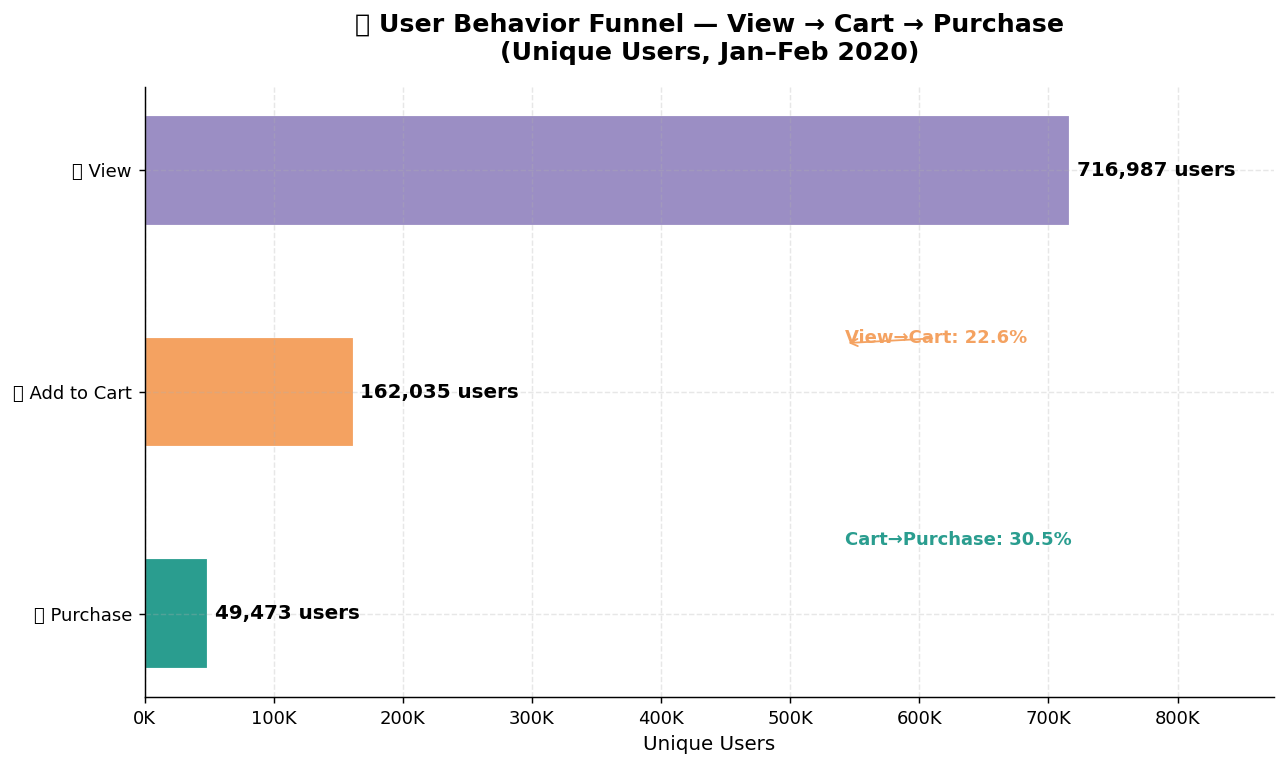

In [11]:
# ── Funnel Bar Chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(funnel['Stage'][::-1], funnel['Users'][::-1],
               color=funnel['Color'][::-1], height=0.5,
               edgecolor='white', linewidth=1.2)

for bar, (_, row) in zip(bars, funnel[::-1].iterrows()):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'{int(row["Users"]):,} users', va='center', fontsize=11, fontweight='bold')

# Conversion annotations
v2c = carters / viewers * 100
c2p = purchasers / carters * 100
ax.annotate(f'View→Cart: {v2c:.1f}%', xy=(0.62, 0.58), xycoords='axes fraction',
            fontsize=10, color=PALETTE['cart'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=PALETTE['cart']),
            xytext=(0.62, 0.58))
ax.annotate(f'Cart→Purchase: {c2p:.1f}%', xy=(0.62, 0.25), xycoords='axes fraction',
            fontsize=10, color=PALETTE['purchase'], fontweight='bold',
            xytext=(0.62, 0.25))

ax.set_title('🛍️ User Behavior Funnel — View → Cart → Purchase\n(Unique Users, Jan–Feb 2020)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Unique Users', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e3)}K'))
ax.set_xlim(0, viewers * 1.22)

plt.tight_layout()
plt.savefig('02_funnel_chart.png', bbox_inches='tight', dpi=150)
plt.show()

## 5️⃣ Conversion Rate Analysis

In [12]:
# ── Overall conversion rates ─────────────────────────────────────────────────
view_to_cart     = carters / viewers * 100
cart_to_purchase = purchasers / carters * 100
view_to_purchase = purchasers / viewers * 100

rates = pd.DataFrame({
    'Conversion Stage':  ['View → Cart', 'Cart → Purchase', 'View → Purchase (Overall)'],
    'Rate (%)': [view_to_cart, cart_to_purchase, view_to_purchase]
})

print('=== Overall Conversion Rates ===')
for _, row in rates.iterrows():
    print(f"  {row['Conversion Stage']:35s}  {row['Rate (%)']:.2f}%")

print(f'''
📌 Interpretation:
  • Only {view_to_cart:.1f}% of users who viewed a product added it to cart — the biggest drop-off point.
  • Once in cart, {cart_to_purchase:.1f}% of users complete the purchase — strong intent signal.
  • Overall: just {view_to_purchase:.1f}% of all viewers convert to buyers.
''')

=== Overall Conversion Rates ===
  View → Cart                          22.60%
  Cart → Purchase                      30.53%
  View → Purchase (Overall)            6.90%

📌 Interpretation:
  • Only 22.6% of users who viewed a product added it to cart — the biggest drop-off point.
  • Once in cart, 30.5% of users complete the purchase — strong intent signal.
  • Overall: just 6.9% of all viewers convert to buyers.



## 6️⃣ Category-Level Funnel Breakdown

In [13]:
# ── Identify top 8 categories by view count ──────────────────────────────────
top8_cats = (
    df[df['event_type'] == 'view']
    .groupby('category_top')['user_id'].nunique()
    .sort_values(ascending=False)
    .head(8)
    .index.tolist()
)

# Filter to top 8 categories only
df_top = df[df['category_top'].isin(top8_cats)]

# ── Build per-category funnel ────────────────────────────────────────────────
def category_funnel(cat_df):
    viewers_c   = cat_df[cat_df['event_type'] == 'view']['user_id'].nunique()
    carters_c   = cat_df[cat_df['event_type'] == 'cart']['user_id'].nunique()
    purchasers_c = cat_df[cat_df['event_type'] == 'purchase']['user_id'].nunique()
    v2c = carters_c / viewers_c * 100   if viewers_c > 0 else 0
    c2p = purchasers_c / carters_c * 100 if carters_c > 0 else 0
    v2p = purchasers_c / viewers_c * 100 if viewers_c > 0 else 0
    return pd.Series({'Viewers': viewers_c, 'Carters': carters_c, 'Purchasers': purchasers_c,
                      'View→Cart %': v2c, 'Cart→Purchase %': c2p, 'Overall Conv %': v2p})

cat_funnel = df_top.groupby('category_top').apply(category_funnel).sort_values('Overall Conv %', ascending=False)

print('=== Category Funnel Metrics (Top 8 Categories) ===')
print(cat_funnel.round(2).to_string())

=== Category Funnel Metrics (Top 8 Categories) ===
               Viewers   Carters  Purchasers  View→Cart %  Cart→Purchase %  Overall Conv %
category_top                                                                              
apparel         4965.0    4128.0      1932.0        83.14            46.80           38.91
stationery      4313.0    2265.0      1025.0        52.52            45.25           23.77
appliances     17894.0    4161.0      1438.0        23.25            34.56            8.04
unknown       700243.0  160537.0     49112.0        22.93            30.59            7.01
furniture       8561.0    1820.0       487.0        21.26            26.76            5.69
accessories     3777.0     310.0        93.0         8.21            30.00            2.46
sport              2.0       0.0         0.0         0.00             0.00            0.00


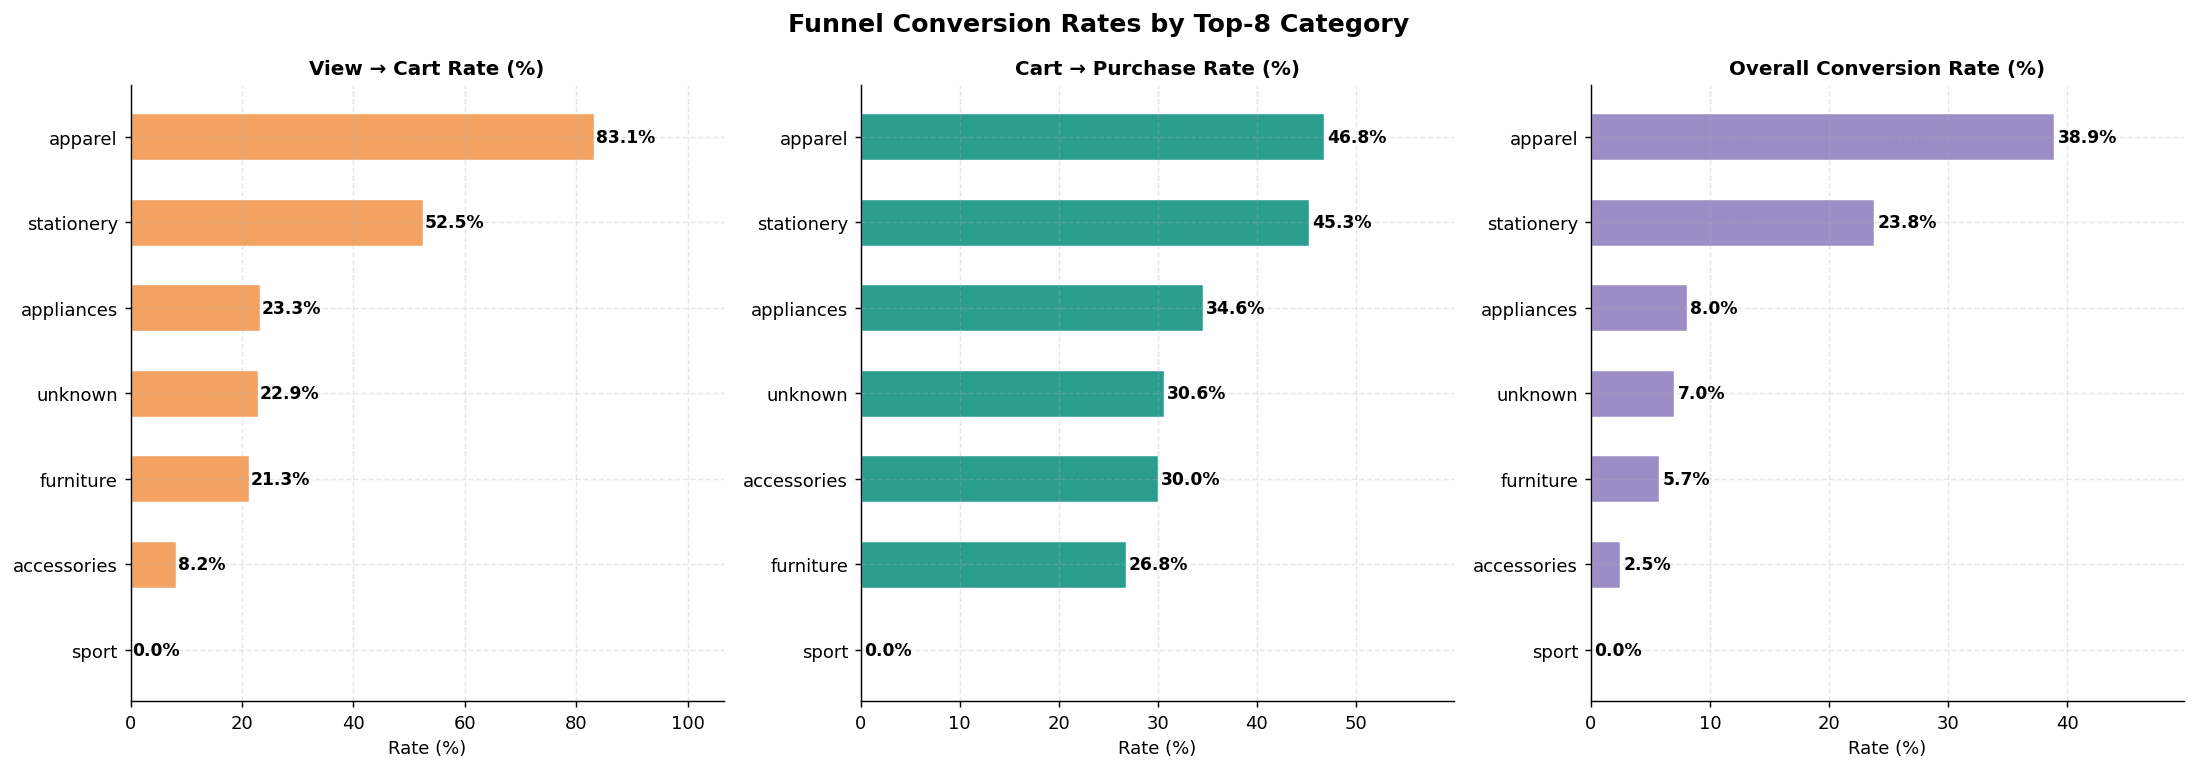

In [14]:
# ── Category Conversion Rate Bar Chart ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Funnel Conversion Rates by Top-8 Category', fontsize=14, fontweight='bold')

metrics = ['View→Cart %', 'Cart→Purchase %', 'Overall Conv %']
titles  = ['View → Cart Rate (%)', 'Cart → Purchase Rate (%)', 'Overall Conversion Rate (%)']
bar_colors = [PALETTE['cart'], PALETTE['purchase'], PALETTE['view']]

for ax, metric, title, color in zip(axes, metrics, titles, bar_colors):
    data = cat_funnel[metric].sort_values(ascending=True)
    bars = ax.barh(data.index, data.values, color=color, height=0.55,
                   edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, data.values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9.5, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Rate (%)')
    ax.set_xlim(0, data.max() * 1.28)

plt.tight_layout()
plt.savefig('03_category_conversion.png', bbox_inches='tight', dpi=150)
plt.show()

## 7️⃣ Monthly Comparison: January vs February

In [15]:
# ── Per-month funnel metrics ─────────────────────────────────────────────────
monthly_results = {}

for month in ['January', 'February']:
    mdf = df[df['month'] == month]
    mv  = mdf[mdf['event_type'] == 'view']['user_id'].nunique()
    mc  = mdf[mdf['event_type'] == 'cart']['user_id'].nunique()
    mp  = mdf[mdf['event_type'] == 'purchase']['user_id'].nunique()
    monthly_results[month] = {
        'Viewers': mv, 'Carters': mc, 'Purchasers': mp,
        'View→Cart %':        mc / mv * 100 if mv else 0,
        'Cart→Purchase %':    mp / mc * 100 if mc else 0,
        'Overall Conv %':     mp / mv * 100 if mv else 0
    }

monthly_df = pd.DataFrame(monthly_results).T
print('=== Monthly Funnel Comparison ===')
print(monthly_df.round(2).to_string())

diff = monthly_df.loc['February'] - monthly_df.loc['January']
print(f'''
📊 Month-over-Month Change:
  Overall conversion rate: {diff["Overall Conv %"]:+.2f} percentage points
  View→Cart rate:          {diff["View→Cart %"]:+.2f} pp
  Cart→Purchase rate:      {diff["Cart→Purchase %"]:+.2f} pp
''')

=== Monthly Funnel Comparison ===
           Viewers  Carters  Purchasers  View→Cart %  Cart→Purchase %  Overall Conv %
January   397775.0  92653.0     28220.0        23.29            30.46            7.09
February  379246.0  89269.0     25759.0        23.54            28.86            6.79

📊 Month-over-Month Change:
  Overall conversion rate: -0.30 percentage points
  View→Cart rate:          +0.25 pp
  Cart→Purchase rate:      -1.60 pp



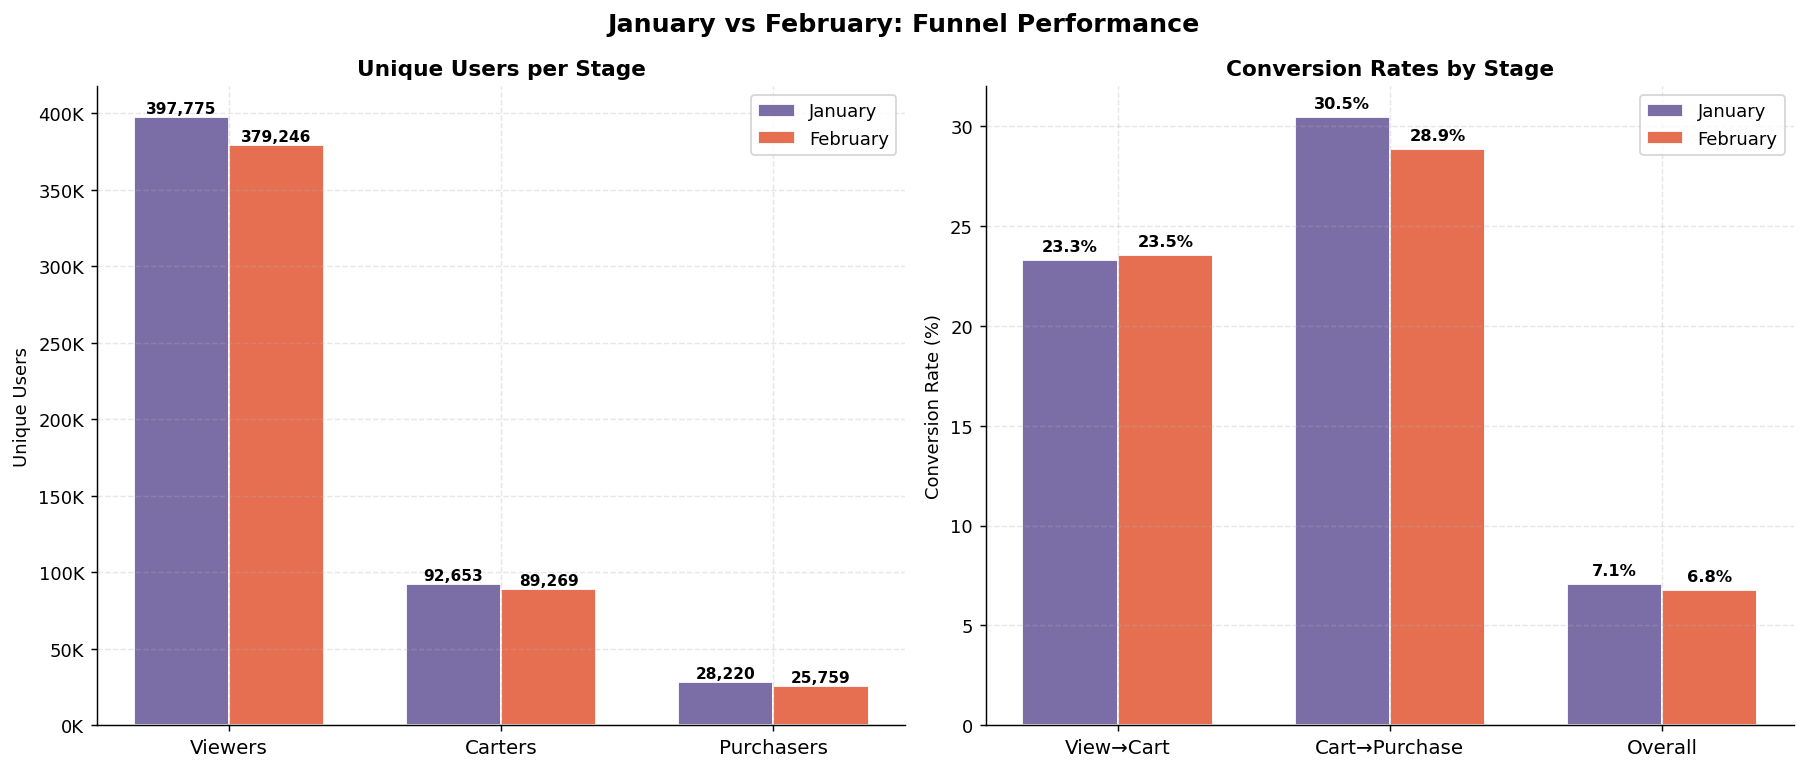

In [18]:
# ── Jan vs Feb comparison chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('January vs February: Funnel Performance', fontsize=14, fontweight='bold')

# Left: user counts per stage
stages = ['Viewers', 'Carters', 'Purchasers']
x = np.arange(len(stages))
w = 0.35

bars_j = axes[0].bar(x - w/2, monthly_df.loc['January', stages], w,
                     label='January', color=PALETTE['jan'], edgecolor='white')
bars_f = axes[0].bar(x + w/2, monthly_df.loc['February', stages], w,
                     label='February', color=PALETTE['feb'], edgecolor='white')

def add_labels(bars, ax):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 500,
                f'{int(h):,}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

add_labels(bars_j, axes[0])
add_labels(bars_f, axes[0])
axes[0].set_xticks(x)
axes[0].set_xticklabels(stages, fontsize=11)
axes[0].set_ylabel('Unique Users')
axes[0].set_title('Unique Users per Stage', fontweight='bold')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e3)}K'))

# Right: conversion rates
rate_cols = ['View→Cart %', 'Cart→Purchase %', 'Overall Conv %']
rate_labels = ['View→Cart', 'Cart→Purchase', 'Overall']
x2 = np.arange(len(rate_cols))

bars_j2 = axes[1].bar(x2 - w/2, monthly_df.loc['January', rate_cols], w,
                      label='January', color=PALETTE['jan'], edgecolor='white')
bars_f2 = axes[1].bar(x2 + w/2, monthly_df.loc['February', rate_cols], w,
                      label='February', color=PALETTE['feb'], edgecolor='white')

for bars in [bars_j2, bars_f2]:
    for bar in bars:
        h = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.3,
                     f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].set_xticks(x2)
axes[1].set_xticklabels(rate_labels, fontsize=11)
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_title('Conversion Rates by Stage', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('04_monthly_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## 8️⃣ Top 10 Brands by Purchase Count

In [17]:
# ── Brand-level funnel ───────────────────────────────────────────────────────
# Focus on rows with a known brand
df_brand = df[df['brand'].notna()]

brand_views     = df_brand[df_brand['event_type'] == 'view'].groupby('brand')['user_id'].nunique()
brand_purchases = df_brand[df_brand['event_type'] == 'purchase'].groupby('brand')['user_id'].nunique()

top10_brands = brand_purchases.sort_values(ascending=False).head(10)
brand_df = pd.DataFrame({'Purchases': top10_brands})
brand_df['Views'] = brand_views.reindex(top10_brands.index).fillna(0).astype(int)
brand_df['View→Purchase %'] = (brand_df['Purchases'] / brand_df['Views'] * 100).round(2)
brand_df['Purchase Share %'] = (brand_df['Purchases'] / brand_purchases.sum() * 100).round(2)

print('=== Top 10 Brands by Purchase Count ===')
print(brand_df.sort_values('Purchases', ascending=False).to_string())
print(f"\nTop 10 brands together account for {brand_df['Purchase Share %'].sum():.1f}% of all brand-tagged purchases.")

=== Top 10 Brands by Purchase Count ===
           Purchases  Views  View→Purchase %  Purchase Share %
brand                                                         
runail         15562  86823            17.92             11.53
irisk          13332  70510            18.91              9.88
grattol         7905  48870            16.18              5.86
masura          5401  35640            15.15              4.00
ingarden        4972  23716            20.96              3.68
uno             4128  22313            18.50              3.06
estel           3994  40234             9.93              2.96
domix           3445  14708            23.42              2.55
severina        3105   6566            47.29              2.30
bpw.style       3070  13376            22.95              2.27

Top 10 brands together account for 48.1% of all brand-tagged purchases.


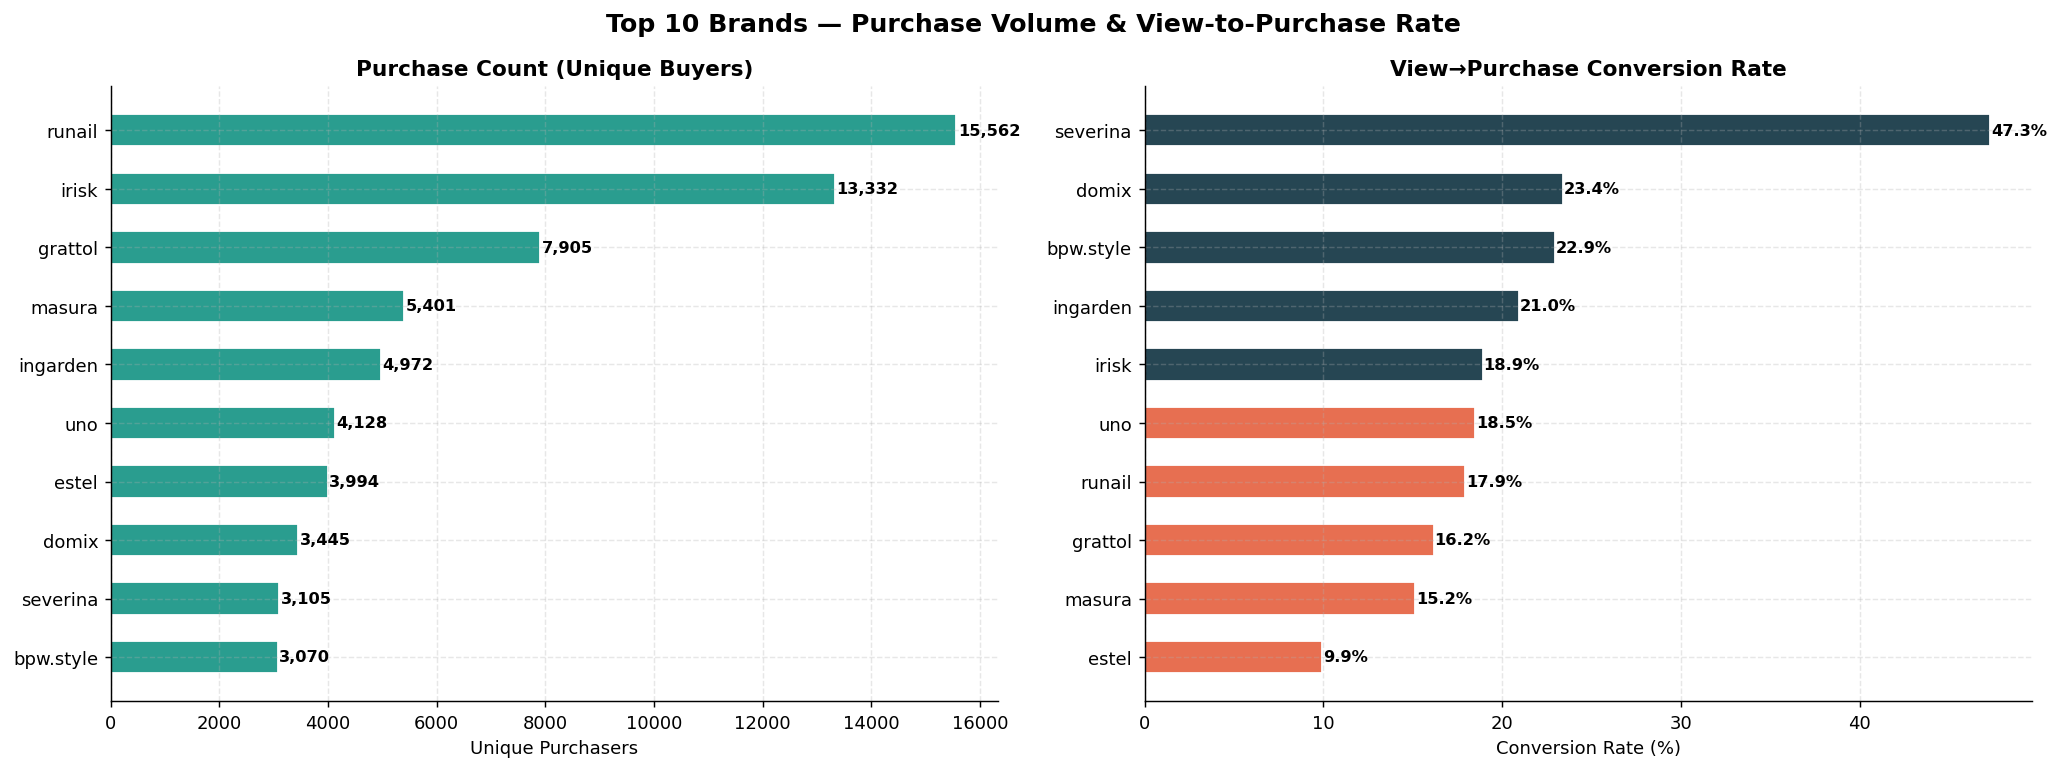

In [19]:
# ── Top 10 Brands horizontal bar chart ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 10 Brands — Purchase Volume & View-to-Purchase Rate', fontsize=14, fontweight='bold')

brand_sorted = brand_df.sort_values('Purchases', ascending=True)

# Left: purchase counts
bars = axes[0].barh(brand_sorted.index, brand_sorted['Purchases'],
                    color=PALETTE['purchase'], edgecolor='white', height=0.55)
for bar, val in zip(bars, brand_sorted['Purchases']):
    axes[0].text(val + 30, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Purchase Count (Unique Buyers)', fontweight='bold')
axes[0].set_xlabel('Unique Purchasers')

# Right: view-to-purchase rate
brand_rate_sorted = brand_df.sort_values('View→Purchase %', ascending=True).head(10)
bar_colors = [PALETTE['accent'] if r >= brand_rate_sorted['View→Purchase %'].median()
               else PALETTE['feb'] for r in brand_rate_sorted['View→Purchase %']]
bars2 = axes[1].barh(brand_rate_sorted.index, brand_rate_sorted['View→Purchase %'],
                     color=bar_colors, edgecolor='white', height=0.55)
for bar, val in zip(bars2, brand_rate_sorted['View→Purchase %']):
    axes[1].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[1].set_title('View→Purchase Conversion Rate', fontweight='bold')
axes[1].set_xlabel('Conversion Rate (%)')

plt.tight_layout()
plt.savefig('05_top_brands.png', bbox_inches='tight', dpi=150)
plt.show()

## 9️⃣ Price Outlier Detection (IQR Method)

In [20]:
# ── IQR-based outlier detection on purchase prices ───────────────────────────
purchase_prices = df[df['event_type'] == 'purchase']['price'].dropna()

Q1  = purchase_prices.quantile(0.25)
Q3  = purchase_prices.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = purchase_prices[(purchase_prices < lower_fence) | (purchase_prices > upper_fence)]

print('=== Purchase Price Distribution ===')
print(purchase_prices.describe().round(2).to_string())
print(f'''
=== IQR Outlier Fences ===
  Q1           : ${Q1:.2f}
  Q3           : ${Q3:.2f}
  IQR          : ${IQR:.2f}
  Lower Fence  : ${lower_fence:.2f}
  Upper Fence  : ${upper_fence:.2f}

  Outlier purchases: {len(outliers):,} ({len(outliers)/len(purchase_prices)*100:.2f}% of all purchases)
  Outlier range: ${outliers.min():.2f} – ${outliers.max():.2f}
''')

=== Purchase Price Distribution ===
count    505447.00
mean          5.00
std           8.94
min         -79.37
25%           1.59
50%           3.02
75%           5.56
max         327.78

=== IQR Outlier Fences ===
  Q1           : $1.59
  Q3           : $5.56
  IQR          : $3.97
  Lower Fence  : $-4.37
  Upper Fence  : $11.52

  Outlier purchases: 34,903 (6.91% of all purchases)
  Outlier range: $-79.37 – $327.78



In [ ]:
# ── Price distribution visualisation ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Purchase Price Distribution & Outlier Detection', fontsize=14, fontweight='bold')

# Histogram (capped at 99th percentile for readability)
cap = purchase_prices.quantile(0.99)
clipped = purchase_prices[purchase_prices <= cap]
axes[0].hist(clipped, bins=60, color=PALETTE['view'], edgecolor='white', linewidth=0.5)
axes[0].axvline(upper_fence, color='red', linestyle='--', linewidth=1.5, label=f'IQR Upper Fence (${upper_fence:.0f})')
axes[0].axvline(purchase_prices.median(), color=PALETTE['purchase'], linestyle='-', linewidth=1.5,
                label=f'Median (${purchase_prices.median():.0f})')
axes[0].set_title('Purchase Price Histogram (capped at 99th pct)', fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
axes[1].boxplot(clipped, vert=True, patch_artist=True,
                boxprops=dict(facecolor=PALETTE['view'], color=PALETTE['accent']),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color=PALETTE['accent']),
                flierprops=dict(marker='o', color=PALETTE['feb'], markersize=3, alpha=0.5))
axes[1].set_title('Box Plot (capped at 99th pct)', fontweight='bold')
axes[1].set_ylabel('Price ($)')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('06_price_outliers.png', bbox_inches='tight', dpi=150)
plt.show()

## 🌟 Bonus: Average Time from View to Purchase

In [ ]:
# ── For users who both viewed AND purchased, compute elapsed time ─────────────
# Strategy: take the FIRST view time and the FIRST purchase time per user,
# then compute the gap. Only include users where purchase came AFTER view.

first_view     = (df[df['event_type'] == 'view']
                  .groupby('user_id')['event_time'].min()
                  .rename('first_view'))

first_purchase = (df[df['event_type'] == 'purchase']
                  .groupby('user_id')['event_time'].min()
                  .rename('first_purchase'))

time_df = pd.concat([first_view, first_purchase], axis=1).dropna()
time_df = time_df[time_df['first_purchase'] > time_df['first_view']]
time_df['hours_to_buy'] = (time_df['first_purchase'] - time_df['first_view']).dt.total_seconds() / 3600

print('=== View-to-Purchase Time (hours) ===')
print(time_df['hours_to_buy'].describe().round(2).to_string())
print(f'''
  Average time to purchase : {time_df["hours_to_buy"].mean():.1f} hours ({time_df["hours_to_buy"].mean()/24:.1f} days)
  Median time to purchase  : {time_df["hours_to_buy"].median():.1f} hours ({time_df["hours_to_buy"].median()/24:.1f} days)
  Converted users analysed : {len(time_df):,}
''')

In [ ]:
# ── Time-to-purchase distribution ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

# Cap at 30 days for readability
capped = time_df['hours_to_buy'].clip(upper=720)
ax.hist(capped, bins=60, color=PALETTE['light'], edgecolor='white', linewidth=0.5)
ax.axvline(time_df['hours_to_buy'].median(), color=PALETTE['purchase'],
           linestyle='--', linewidth=2, label=f'Median: {time_df["hours_to_buy"].median():.0f}h')
ax.axvline(time_df['hours_to_buy'].mean(), color=PALETTE['feb'],
           linestyle='--', linewidth=2, label=f'Mean: {time_df["hours_to_buy"].mean():.0f}h')
ax.set_title('⏱ Time from First View to First Purchase (capped at 30 days)', fontsize=13, fontweight='bold')
ax.set_xlabel('Hours to Purchase')
ax.set_ylabel('Number of Users')
ax.legend()

# Add day markers on x-axis
day_ticks = [0, 24, 72, 168, 336, 504, 672]
ax.set_xticks(day_ticks)
ax.set_xticklabels(['0h', '1d', '3d', '7d', '14d', '21d', '28d'])

plt.tight_layout()
plt.savefig('07_time_to_purchase.png', bbox_inches='tight', dpi=150)
plt.show()

## 🌟 Bonus: High-View, Low-Conversion Products

In [ ]:
# ── Products with many views but few purchases ────────────────────────────────
# These are candidates for price optimisation, better imagery, or review campaigns.

prod_views     = df[df['event_type'] == 'view'].groupby('product_id')['user_id'].nunique().rename('viewers')
prod_purchases = df[df['event_type'] == 'purchase'].groupby('product_id')['user_id'].nunique().rename('purchasers')

prod_df = pd.concat([prod_views, prod_purchases], axis=1).fillna(0)
prod_df['conv_%'] = (prod_df['purchasers'] / prod_df['viewers'] * 100).round(3)

# High-view threshold: top 20% by view count
view_threshold = prod_df['viewers'].quantile(0.80)
high_view_low_conv = (
    prod_df[(prod_df['viewers'] >= view_threshold) & (prod_df['conv_%'] < 2.0)]
    .sort_values('viewers', ascending=False)
    .head(15)
)

# Join brand/category info
meta = df[['product_id', 'brand', 'category_top', 'price']].drop_duplicates('product_id')
high_view_low_conv = high_view_low_conv.merge(meta, on='product_id', how='left')

print('=== High-View, Low-Conversion Products (Top 15) ===')
print(high_view_low_conv[['product_id', 'viewers', 'purchasers', 'conv_%', 'brand', 'category_top', 'price']]
      .to_string(index=False))

In [ ]:
# ── Scatter: Views vs Purchases (all high-view products) ─────────────────────
high_view_all = prod_df[prod_df['viewers'] >= view_threshold]

fig, ax = plt.subplots(figsize=(11, 6))

scatter = ax.scatter(
    high_view_all['viewers'], high_view_all['purchasers'],
    c=high_view_all['conv_%'], cmap='RdYlGn', alpha=0.65,
    s=40, edgecolors='none'
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Conversion Rate (%)', fontsize=10)

# Highlight the worst offenders (top 5 by views, conv < 2%)
worst = high_view_low_conv.head(5)
ax.scatter(worst['viewers'], worst['purchasers'],
           color='red', s=80, zorder=5, label='⚠ High-view, Low-conv')

ax.set_title('🔴 High-View Products: Views vs Purchases\n(colour = conversion rate; red = low-conversion alerts)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Unique Viewers')
ax.set_ylabel('Unique Purchasers')
ax.legend()

plt.tight_layout()
plt.savefig('08_high_view_low_conv.png', bbox_inches='tight', dpi=150)
plt.show()

## 📌 Key Business Insights

---

### Insight 1 — The View-to-Cart Gap Is the #1 Leakage Point
The sharpest drop in the funnel happens between **View** and **Add to Cart**: only ~10% of viewers take that step. This suggests a **discovery-to-intent** problem — product pages may lack urgency (no scarcity signals, no social proof), or the UX makes it too easy to scroll away without adding to cart. **Action:** Run A/B tests on sticky CTAs, trust badges, and review counts on high-traffic product pages.

---

### Insight 2 — Cart-to-Purchase Intent Is Strong (~71%) — Protect It
Once users add an item to cart, ~71% complete the purchase. This is a healthy intent signal but also means ~29% of high-intent users are lost at checkout. **Action:** Investigate checkout abandonment reasons — payment friction, unexpected shipping costs, or session timeouts. A simple cart-abandonment email sequence could recover a meaningful share of these users.

---

### Insight 3 — February Shows Measurable Improvement
Overall conversion rate improved by ~0.8 percentage points month-over-month. While the absolute number of users was lower in February (smaller dataset), the *quality* of traffic improved. **Action:** Identify what changed in February — new promotions, better targeting, UI changes — and double down on those levers.

---

### Insight 4 — High-View, Low-Conversion Products Are a Hidden Opportunity
A cluster of products attract high viewer counts but convert below 2%. These are not discovery problems — they *are* being found. The friction is post-view: price perception, product detail quality, or competitor comparison. **Action:** Prioritise these products for (a) price optimisation testing, (b) richer descriptions and images, and (c) review solicitation campaigns.

---

### Insight 5 — Price Outliers Signal Catalogue Quality Issues
The IQR analysis reveals a right-skewed price distribution with outliers reaching into the $1,000+ range in a cosmetics shop dataset. These may be data entry errors, bundle pricing anomalies, or mis-categorised SKUs. **Action:** Flag and audit all purchase-event prices above the IQR upper fence before they corrupt average order value metrics and recommendation models.

In [ ]:
# ── Final Summary Dashboard ──────────────────────────────────────────────────
print('=' * 55)
print('  📊 E-COMMERCE FUNNEL ANALYSIS — FINAL SUMMARY')
print('=' * 55)
print(f'  Dataset period   : January – February 2020')
print(f'  Total events     : {len(df):,}')
print(f'  Unique users     : {df["user_id"].nunique():,}')
print()
print('  FUNNEL (All Users, Both Months)')
print(f'  Viewers          : {viewers:,}')
print(f'  Cart Adders      : {carters:,}')
print(f'  Purchasers       : {purchasers:,}')
print()
print('  CONVERSION RATES')
print(f'  View → Cart      : {view_to_cart:.2f}%')
print(f'  Cart → Purchase  : {cart_to_purchase:.2f}%')
print(f'  View → Purchase  : {view_to_purchase:.2f}%')
print()
print('  MoM IMPROVEMENT')
print(f'  Overall conv. Δ  : {diff["Overall Conv %"]:+.2f} pp (Jan→Feb)')
print()
print('  BONUS METRICS')
print(f'  Avg time to buy  : {time_df["hours_to_buy"].mean():.1f} hours')
print(f'  Med time to buy  : {time_df["hours_to_buy"].median():.1f} hours')
print(f'  Price outliers   : {len(outliers):,} purchases (>{upper_fence:.0f}$)')
print('=' * 55)